#  Comparative Evaluation: Combined vs. Single4 Runs

This notebook evaluates two DeepSight run strategies:

- **Combined run**: All DICOM images processed together in one batch.
- **Single4 runs**: Each image processed individually (4 separate runs).

---

##  Insights

###  DICOM-Level Comparison
|  Observation                          | Result |
|----------------------------------------|--------|
| Max detection score per DICOM image    | **Identical** between Combined and Single4 |
| Matching image IDs                     | All 4 DICOMs from Combined were matched to corresponding Single4 results |
| Δ (Combined − Single4) per image       | **0.0** for all images |

---

###  Study-Level Results
| Run         | 🩺 L Score | 🩻 R Score |  Total Score |
|-------------|-----------|-----------|----------------|
| Combined    | 0.7258    | 0.0459    | 0.7258         |
| single4/01  | 0.7945    | —         | 0.7945         |
| single4/02  | 0.6571    | —         | 0.6571         |
| single4/03  | —         | 0.0429    | 0.0429         |
| single4/04  | —         | 0.0488    | 0.0488         |

> ℹ **Note:** Each Single4 run processes only one DICOM (either Left or Right).

---

### Analysis

- 🧠 **Combined run** = Aggregated summary of Single4 runs.
- 🎯 **L Score (Combined)** ≈ Average of `single4/01` and `single4/02`
- 🎯 **R Score (Combined)** ≈ Average of `single4/03` and `single4/04`
- 🔄 **Max scores per image** are identical across both methods.

---

##  Conclusion

There is **no difference in detection performance** between Combined and Single4 runs.  
The Combined run simply **aggregates** the results of all Single4 runs — making it more convenient, but not more accurate.



In [ ]:
import os
import json


In [ ]:
#  Step 2 – define your paths
BASE_DIR           = "/raid/mpsych/OMAMA/2025/PLAYGROUND/TEST04152025/OUT"
COMBINED_JSON_PATH = os.path.join(
    BASE_DIR, "combined", "combined", "results_full.json"
)
SINGLE4_DIR        = os.path.join(BASE_DIR, "single4")


In [ ]:
#  Step 3 – load & print the Combined run JSON
if os.path.exists(COMBINED_JSON_PATH):
    with open(COMBINED_JSON_PATH, "r") as f:
        combined = json.load(f)
    print("=== Combined JSON ===")
    print(json.dumps(combined, indent=4))
else:
    print("Combined JSON not found at:", COMBINED_JSON_PATH)


=== Combined JSON ===
{
    "input_dir": "/home/daniel.haehn/TEST04152025/combined",
    "input_files": [
        "/home/daniel.haehn/TEST04152025/combined/DXm.2.25.173803440485307451614987519907264671779",
        "/home/daniel.haehn/TEST04152025/combined/DXm.2.25.109865729760992638360694443409251815567",
        "/home/daniel.haehn/TEST04152025/combined/DXm.2.25.106924144890407873251702717161766133956",
        "/home/daniel.haehn/TEST04152025/combined/DXm.2.25.213465259260888069289877692759291753499"
    ],
    "output_dir": "/root/output/combined",
    "_metadata": "{\"failed_checks\":{\"0\":null,\"1\":null,\"2\":null,\"3\":null},\"dcm_path\":{\"0\":\"\\/home\\/daniel.haehn\\/TEST04152025\\/combined\\/DXm.2.25.173803440485307451614987519907264671779\",\"1\":\"\\/home\\/daniel.haehn\\/TEST04152025\\/combined\\/DXm.2.25.109865729760992638360694443409251815567\",\"2\":\"\\/home\\/daniel.haehn\\/TEST04152025\\/combined\\/DXm.2.25.106924144890407873251702717161766133956\",\"3\":\"\\/hom

In [ ]:
#  Step 4 – load & print each of your single4 sub‑runs
print("=== single4 JSONs ===")
for sd in sorted(os.listdir(SINGLE4_DIR)):
    fn = os.path.join(SINGLE4_DIR, sd, "results_full.json")
    if os.path.exists(fn):
        with open(fn, "r") as f:
            data = json.load(f)
        print(f"\n--- single4/{sd} ---")
        print(json.dumps(data, indent=4))
    else:
        print(f"\n--- single4/{sd} has no results_full.json")


=== single4 JSONs ===

--- single4/01 ---
{
    "input_dir": "/home/daniel.haehn/TEST04152025/single/01",
    "input_files": [
        "/home/daniel.haehn/TEST04152025/single/01/DXm.2.25.106924144890407873251702717161766133956"
    ],
    "output_dir": "/root/output/01",
    "_metadata": "{\"failed_checks\":{\"0\":null},\"dcm_path\":{\"0\":\"\\/home\\/daniel.haehn\\/TEST04152025\\/single\\/01\\/DXm.2.25.106924144890407873251702717161766133956\"},\"AccessionNumber\":{\"0\":\"DHYERLXXIK71\"},\"Columns\":{\"0\":\"1996\"},\"CompressionForce\":{\"0\":\"126.7737\"},\"ContentDate\":{\"0\":\"\"},\"ContentTime\":{\"0\":\"\"},\"DetectorBinning\":{\"0\":\"[2, 2]\"},\"Exposure\":{\"0\":\"79\"},\"FieldOfViewHorizontalFlip\":{\"0\":\"NO\"},\"FieldOfViewOrigin\":{\"0\":\"[0, 120]\"},\"FieldOfViewRotation\":{\"0\":\"180\"},\"FrameOfReferenceUID\":{\"0\":\"2.25.105870638754529821718726632380288502447\"},\"ImageLaterality\":{\"0\":\"L\"},\"ImagerPixelSpacing\":{\"0\":\"[0.105787, 0.105787]\"},\"ImageTyp

In [ ]:
#  Step 5 – build & display the total‐score comparison table
import pandas as pd

# 1) get combined total
combined_total = combined["results"]["study_results"]["total"]["score"]

# 2) collect all single4 totals
single_rows = []
for sd in sorted(os.listdir(SINGLE4_DIR)):
    fn = os.path.join(SINGLE4_DIR, sd, "results_full.json")
    if os.path.exists(fn):
        with open(fn, "r") as f:
            d = json.load(f)
        tot = d["results"]["study_results"]["total"]["score"]
        single_rows.append({"Run": f"single4/{sd}", "Total Score": tot})

# 3) assemble DataFrame
df = pd.DataFrame([{"Run": "combined", "Total Score": combined_total}] + single_rows)
df["Δ vs combined"] = (df["Total Score"].iloc[0] - df["Total Score"]).round(4)
df = df.round(4)

print("🔍 Total‐Score Comparison")
display(df)


🔍 Total‐Score Comparison


,Run,Total Score,Δ vs combined
0,combined,0.7258,0.0000
1,single4/01,0.7945,-0.0687
2,single4/02,0.6571,0.0687
3,single4/03,0.0429,0.6829
4,single4/04,0.0488,0.6770


In [ ]:
# %% Step 6 – tabular view of the combined run’s study_results
import json
import pandas as pd

# Correct combined JSON path
with open(os.path.join(BASE_DIR, "combined", "combined", "results_full.json"), "r") as f:
    combined = json.load(f)

# Extract study_results into a table
combined_rows = []
for metric, info in combined["results"]["study_results"].items():
    row = {"Metric": metric}
    row.update(info)
    combined_rows.append(row)

df_combined = pd.DataFrame(combined_rows)
cols = ["Metric"] + [c for c in df_combined.columns if c != "Metric"]
df_combined = df_combined[cols]

print("📋 Combined run — study_results:")
display(df_combined)


📋 Combined run — study_results:


,Metric,score,category,category_name,postprocessed_percentile_score
0,L,0.725828,1,Suspicious,NaN
1,R,0.045854,0,,NaN
2,total,0.725828,1,Suspicious,98.500111


In [ ]:
# %% Step 7 – tabular view of all single4 study_results
single_rows = []

for sd in sorted(os.listdir(SINGLE4_DIR)):
    fn = os.path.join(SINGLE4_DIR, sd, "results_full.json")
    if os.path.exists(fn):
        with open(fn, "r") as f:
            data = json.load(f)
        for metric, info in data["results"]["study_results"].items():
            row = {"Run": f"single4/{sd}", "Metric": metric}
            row.update(info)
            single_rows.append(row)

df_single4 = pd.DataFrame(single_rows)
cols = ["Run", "Metric"] + [c for c in df_single4.columns if c not in ("Run", "Metric")]
df_single4 = df_single4[cols]

print("📋 single4 runs — study_results:")
display(df_single4)


📋 single4 runs — study_results:


,Run,Metric,score,category,category_name,postprocessed_percentile_score
0,single4/01,L,0.794531,1,Suspicious,NaN
1,single4/01,total,0.794531,1,Suspicious,99.604696
2,single4/02,L,0.657126,1,Suspicious,NaN
3,single4/02,total,0.657126,1,Suspicious,97.190562
4,single4/03,R,0.042909,0,,NaN
5,single4/03,total,0.042909,0,,4.686703
6,single4/04,R,0.048799,0,,NaN
7,single4/04,total,0.048799,0,,6.381244


In [ ]:
# %% Step 8 – Compare detection scores per DICOM ID
dicom_rows = []

# 1. Load Combined DICOM scores
combined_dicoms = combined["results"]["dicom_results"]
for dxm_id, result in combined_dicoms.items():
    max_comb_score = max(d["score"] for d in result.get("none", []))

    # Try to find matching DICOM in single4
    match_found = False
    for sd in sorted(os.listdir(SINGLE4_DIR)):
        fn = os.path.join(SINGLE4_DIR, sd, "results_full.json")
        if os.path.exists(fn):
            with open(fn, "r") as f:
                s4_data = json.load(f)
            s4_dicoms = s4_data["results"]["dicom_results"]
            if dxm_id in s4_dicoms:
                max_s4_score = max(d["score"] for d in s4_dicoms[dxm_id].get("none", []))
                dicom_rows.append({
                    "DICOM ID": dxm_id,
                    "Combined Score": round(max_comb_score, 4),
                    "Single4 Run": f"single4/{sd}",
                    "Single4 Score": round(max_s4_score, 4),
                    "Δ (Combined − Single4)": round(max_comb_score - max_s4_score, 4)
                })
                match_found = True
                break
    if not match_found:
        dicom_rows.append({
            "DICOM ID": dxm_id,
            "Combined Score": round(max_comb_score, 4),
            "Single4 Run": "Not Found",
            "Single4 Score": None,
            "Δ (Combined − Single4)": None
        })

# 2. Create DataFrame
df_dicom_compare = pd.DataFrame(dicom_rows)
print("📋 DICOM-based comparison between Combined and Single4 runs:")
display(df_dicom_compare)


📋 DICOM-based comparison between Combined and Single4 runs:


,DICOM ID,Combined Score,Single4 Run,Single4 Score,Δ (Combined − Single4)
0,2.25.173803440485307451614987519907264671779,0.6571,single4/02,0.6571,0.0
1,2.25.109865729760992638360694443409251815567,0.0429,single4/03,0.0429,0.0
2,2.25.106924144890407873251702717161766133956,0.7945,single4/01,0.7945,0.0
3,2.25.213465259260888069289877692759291753499,0.0488,single4/04,0.0488,0.0


- **Chart 1** (Total Score by Run):
  - Displays the overall study-level total score for each run.
  - Helps visually compare how close each Single4 run is to the Combined result.

- **Chart 2** (Left vs Right Score by Run):
  - Shows left (L) and right (R) side scores individually.
  - Highlights how each Single4 run only contributes either L or R, while the Combined merges both.

<ipython-input-1-295d1c10b4e9>:16: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


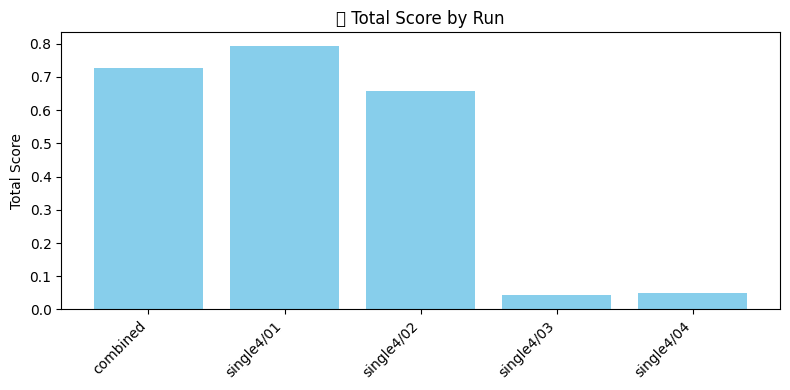

<ipython-input-1-295d1c10b4e9>:33: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


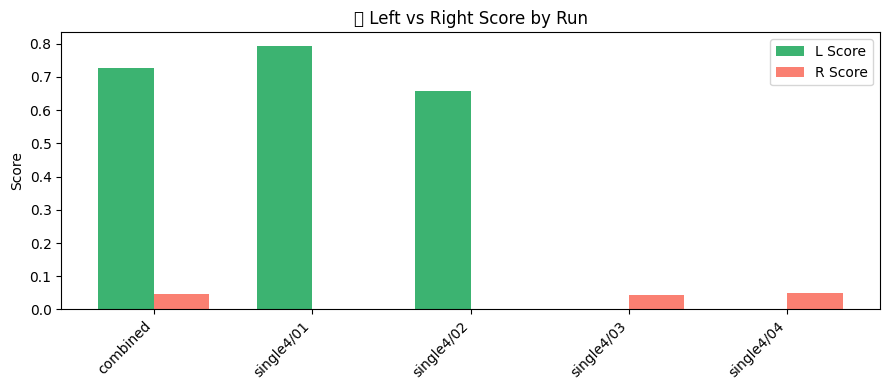

In [1]:
# %% Cell – Bar Charts: Total Score & L/R Scores by Run
import matplotlib.pyplot as plt

# Data setup
run_names = ["combined", "single4/01", "single4/02", "single4/03", "single4/04"]
total_scores = [0.7258, 0.7945, 0.6571, 0.0429, 0.0488]
left_scores  = [0.7258, 0.7945, 0.6571, None, None]
right_scores = [0.0459, None, None, 0.0429, 0.0488]

# 1️⃣ Total Score by Run
plt.figure(figsize=(8, 4))
plt.bar(run_names, total_scores, color='skyblue')
plt.title("📊 Total Score by Run")
plt.ylabel("Total Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2️⃣ Left vs Right Score Comparison
x = range(len(run_names))
bar_width = 0.35

plt.figure(figsize=(9, 4))
plt.bar([i - bar_width/2 for i in x], [s if s is not None else 0 for s in left_scores],
        width=bar_width, label='L Score', color='mediumseagreen')
plt.bar([i + bar_width/2 for i in x], [s if s is not None else 0 for s in right_scores],
        width=bar_width, label='R Score', color='salmon')

plt.title("🩺 Left vs Right Score by Run")
plt.ylabel("Score")
plt.xticks(ticks=x, labels=run_names, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()
